# 07 – Lead-Time Analysis 

**Answers sub-question 3**: *How early before a rule-flagged anomalous event can the conformal detector raise a reliable alarm, and how does the trade-off between detection lead time and false-positive rate behave as the significance level ε is varied?*

## What is measured

For each rule-flagged anomalous event in the test set, the lead time is the time (in seconds) between (a) the moment the conformal detector first raises the alarm for the vehicle, and (b) the moment the rule fires.

- Positive lead time: detector flagged *before* the event → useful early warning.
- Zero lead time: detector flagged at the same moment → reactive, no warning.
- Lead time undefined (missed): detector never flagged this trajectory before the event → false negative.

Sub-question 3 asks how this varies with ε: tighter ε → fewer false alarms but later detection; looser ε → earlier detection but more false alarms. The trade-off curve is the answer.

## Variant-specific operationalisation

**Variant A (per-row, feature-based).** For each test trajectory containing at least one rule-flagged row, look at every row of the trajectory in time order. The detection moment is the first row whose `p_value_A < ε`. The event moment is the first row whose `rule_any = True`. Lead time = event moment − detection moment.

**Variant B (per-trajectory, Hausdorff).** As written, B produces only one p-value per trajectory, not per row. For a lead-time analysis we extend it to the SHNN-CAD prefix-based mode: at each prefix length (e.g. first 5%, 10%, ..., 100% of the trajectory), compute the Hausdorff score of that prefix against training prefixes of the same length. The earliest prefix at which p < ε is the detection moment.

Both variants then yield a distribution of lead times across events, evaluated at each ε in {0.5%, 1%, 2%, 5%, 10%}.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
from collections import defaultdict
import time

## 1. Load scored data

In [2]:
IN_PATH = Path('features_scored.parquet')  # output of notebook 06

df = pd.read_parquet(IN_PATH)
if 'cluster' in df.columns:
    df['cluster'] = df['cluster'].apply(lambda c: tuple(c) if hasattr(c, '__iter__') else c)
df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values(['ID', 'Time']).reset_index(drop=True)

print(f'Rows: {len(df):,}, vehicles: {df["ID"].nunique():,}')
print(f'Split counts (rows): {df["split"].value_counts().to_dict()}')
print(f'Test rows with defined p_value_A: {df.loc[df["split"]=="test", "p_value_A"].notna().sum():,}')

Rows: 1,372,369, vehicles: 46,578
Split counts (rows): {'train': 823743, 'test': 275566, 'cal': 273060}
Test rows with defined p_value_A: 237,813


## 2. Lead time for Variant A

For each test vehicle that has at least one rule-flagged row, find the first detected row (`p_value_A < ε`) and the first rule-flagged row. Lead time = event time − detection time.

In [3]:
EPSILONS = [0.005, 0.01, 0.02, 0.05, 0.10]

test_df = df[df['split'] == 'test'].copy()
test_df = test_df.sort_values(['ID', 'Time']).reset_index(drop=True)

def lead_time_per_event_A(test_df, eps):
    """For each test vehicle with a rule-flagged row, return (event_time, detection_time, lead_s).
    If detection never happens before event_time, lead_s is NaN."""
    rows = []
    for vid, sub in test_df.groupby('ID', sort=False):
        sub = sub.dropna(subset=['p_value_A']).reset_index(drop=True)
        if len(sub) == 0: continue
        rule_rows = sub.index[sub['rule_any']].tolist()
        if not rule_rows: continue  # vehicle has no rule-flagged rows in test
        first_event_idx = rule_rows[0]
        event_time = sub.loc[first_event_idx, 'Time']
        # Look only at rows BEFORE the event for the detection moment.
        pre_event = sub.loc[:first_event_idx]
        detected_in_pre = pre_event.index[pre_event['p_value_A'] < eps].tolist()
        if detected_in_pre:
            detection_time = sub.loc[detected_in_pre[0], 'Time']
            lead_s = (event_time - detection_time).total_seconds()
        else:
            detection_time = pd.NaT
            lead_s = np.nan
        rows.append({
            'ID': vid,
            'event_time': event_time,
            'detection_time': detection_time,
            'lead_s': lead_s,
            'eps': eps,
        })
    return pd.DataFrame(rows)

lt_A_per_eps = pd.concat([lead_time_per_event_A(test_df, eps) for eps in EPSILONS], ignore_index=True)

print('=== Variant A lead-time summary ===')
summary_A = lt_A_per_eps.groupby('eps').agg(
    n_events=('lead_s', 'size'),
    n_detected_in_advance=('lead_s', lambda s: (s > 0).sum()),
    n_detected_at_event=('lead_s', lambda s: (s == 0).sum()),
    n_missed=('lead_s', lambda s: s.isna().sum()),
    median_lead_s=('lead_s', lambda s: s[s > 0].median()),
    max_lead_s=('lead_s', lambda s: s.max()),
).reset_index()
print(summary_A.round(2).to_string(index=False))

=== Variant A lead-time summary ===
 eps  n_events  n_detected_in_advance  n_detected_at_event  n_missed  median_lead_s  max_lead_s
0.00      2243                    141                   34      2068           2.93       21.57
0.01      2243                    249                   61      1933           2.78       26.40
0.02      2243                    445                  124      1674           2.78       26.40
0.05      2243                    935                  211      1097           3.03       37.68
0.10      2243                   1421                  244       578           3.23       37.82


## 3. Lead time for Variant B (prefix-based SHNN-CAD)

For each test trajectory in a viable cluster, there's Hausdorff score at successive prefix lengths (e.g. the first 25%, 50%, 75%, 100% of the trajectory) against same-length prefixes of training trajectories. The earliest prefix at which the conformal p-value drops below ε is the detection moment.

This is the per-point analogue of the trajectory-level Variant B from notebook 06.

In [4]:
# Parameters mirror notebook 06.
N_REF_POINTS = 50
K_NN_B = 5
MIN_TRAIN_FOR_CLUSTER = 5
MAX_TRAIN_PER_CLUSTER = 500
PREFIX_FRACTIONS = [0.25, 0.50, 0.75, 1.00]

def resample_trajectory(sub_df, n=N_REF_POINTS):
    xy = sub_df[['X', 'Y']].to_numpy()
    if len(xy) < 2: return None, None
    seg = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    arc = np.concatenate([[0], np.cumsum(seg)])
    if arc[-1] == 0: return None, None
    u = np.linspace(0, arc[-1], n)
    xy_resampled = np.column_stack([np.interp(u, arc, xy[:, 0]), np.interp(u, arc, xy[:, 1])])
    # Also interpolate timestamps onto the same arc-length grid so we can recover detection time.
    t_sec = (sub_df['Time'] - sub_df['Time'].iloc[0]).dt.total_seconds().to_numpy()
    t_resampled = np.interp(u, arc, t_sec)
    return xy_resampled, t_resampled

# Resample everything once, keep timestamps.
rng = np.random.default_rng(seed=42)
traj_xy = {}
traj_t  = {}
split_by_id = {}
anom_by_id = {}
cluster_by_id = {}
any_rule_by_id_first_t = {}  # first time (within trajectory) that rule_any fires

for vid, sub in df.groupby('ID', sort=False):
    r_xy, r_t = resample_trajectory(sub)
    if r_xy is None: continue
    traj_xy[vid] = r_xy
    traj_t[vid]  = r_t
    split_by_id[vid] = sub['split'].iloc[0]
    anom_by_id[vid] = sub['is_anomalous_trajectory'].iloc[0]
    cluster_by_id[vid] = sub['cluster'].iloc[0]
    rule_rows = sub[sub['rule_any']]
    if len(rule_rows) > 0:
        first_t = (rule_rows['Time'].iloc[0] - sub['Time'].iloc[0]).total_seconds()
        any_rule_by_id_first_t[vid] = first_t

train_normal_ids = [vid for vid in traj_xy if split_by_id[vid] == 'train' and not anom_by_id[vid]]
cal_ids  = [vid for vid in traj_xy if split_by_id[vid] == 'cal']
test_ids = [vid for vid in traj_xy if split_by_id[vid] == 'test']
print(f'train-normal: {len(train_normal_ids):,}, cal: {len(cal_ids):,}, test: {len(test_ids):,}')

# Build per-cluster training trajectory pools, sub-sampled.
train_by_cluster = defaultdict(list)
for vid in train_normal_ids:
    train_by_cluster[cluster_by_id[vid]].append(vid)
for c in list(train_by_cluster):
    if MAX_TRAIN_PER_CLUSTER and len(train_by_cluster[c]) > MAX_TRAIN_PER_CLUSTER:
        picked = rng.choice(len(train_by_cluster[c]), size=MAX_TRAIN_PER_CLUSTER, replace=False)
        train_by_cluster[c] = [train_by_cluster[c][i] for i in picked]

train-normal: 20,321, cal: 9,316, test: 9,316


In [5]:
def prefix_hausdorff(query_xy, train_pool_xy, frac, k):
    """Directed Hausdorff from query's first frac% to each training trajectory's first frac%,
    then k-th smallest. Vectorised via per-training-prefix KDTrees."""
    n = max(2, int(N_REF_POINTS * frac))
    q_pref = query_xy[:n]
    dists = np.empty(len(train_pool_xy))
    for i, t_xy in enumerate(train_pool_xy):
        t_pref = t_xy[:n]
        tree = cKDTree(t_pref)
        d, _ = tree.query(q_pref, k=1)
        dists[i] = d.max()
    return np.partition(dists, k-1)[k-1] if len(dists) >= k else np.nan

def conformal_pvalues(scores_test, scores_cal):
    n_cal = len(scores_cal)
    sorted_cal = np.sort(scores_cal)
    pos = np.searchsorted(sorted_cal, scores_test, side='left')
    return (1 + (n_cal - pos)) / (n_cal + 1)

# For each prefix fraction f, compute Hausdorff scores on all cal and test trajectories.
# Then conformal p-values per fraction.
t0 = time.time()
scores_by_frac_cal  = {}
scores_by_frac_test = {}
for f in PREFIX_FRACTIONS:
    cal_scores  = np.full(len(cal_ids),  np.nan)
    test_scores = np.full(len(test_ids), np.nan)
    for j, vid in enumerate(cal_ids):
        c = cluster_by_id[vid]
        pool = [traj_xy[t] for t in train_by_cluster.get(c, [])]
        if len(pool) >= MIN_TRAIN_FOR_CLUSTER and len(pool) >= K_NN_B:
            cal_scores[j] = prefix_hausdorff(traj_xy[vid], pool, f, K_NN_B)
    for j, vid in enumerate(test_ids):
        c = cluster_by_id[vid]
        pool = [traj_xy[t] for t in train_by_cluster.get(c, [])]
        if len(pool) >= MIN_TRAIN_FOR_CLUSTER and len(pool) >= K_NN_B:
            test_scores[j] = prefix_hausdorff(traj_xy[vid], pool, f, K_NN_B)
    scores_by_frac_cal[f]  = cal_scores
    scores_by_frac_test[f] = test_scores
print(f'Prefix Hausdorff computed for {len(PREFIX_FRACTIONS)} fractions in {time.time()-t0:.1f}s')

Prefix Hausdorff computed for 4 fractions in 886.8s


In [6]:
# Lead time: for each test trajectory with a rule event, find the smallest prefix fraction at which
# the conformal p drops below ε. Map that fraction back to a time via traj_t.

def lead_time_B(eps):
    rows = []
    for j, vid in enumerate(test_ids):
        if vid not in any_rule_by_id_first_t:
            continue
        event_t = any_rule_by_id_first_t[vid]
        detection_t = np.nan
        for f in PREFIX_FRACTIONS:
            s_test = scores_by_frac_test[f][j]
            s_cal  = scores_by_frac_cal[f]
            if np.isnan(s_test):
                continue
            valid_cal = s_cal[np.isfinite(s_cal)]
            if len(valid_cal) == 0:
                continue
            p = conformal_pvalues(np.array([s_test]), valid_cal)[0]
            if p < eps:
                n_pref = max(2, int(N_REF_POINTS * f))
                detection_t = traj_t[vid][n_pref - 1]
                break
        lead_s = (event_t - detection_t) if np.isfinite(detection_t) else np.nan
        rows.append({
            'ID': vid,
            'event_t': event_t,
            'detection_t': detection_t,
            'lead_s': lead_s,
            'eps': eps,
        })
    return pd.DataFrame(rows)

lt_B_per_eps = pd.concat([lead_time_B(eps) for eps in EPSILONS], ignore_index=True)

summary_B = lt_B_per_eps.groupby('eps').agg(
    n_events=('lead_s', 'size'),
    n_detected_in_advance=('lead_s', lambda s: (s > 0).sum()),
    n_detected_at_event=('lead_s', lambda s: ((s <= 0) & s.notna()).sum()),
    n_missed=('lead_s', lambda s: s.isna().sum()),
    median_lead_s=('lead_s', lambda s: s[s > 0].median()),
    max_lead_s=('lead_s', lambda s: s.max()),
).reset_index()
print('=== Variant B lead-time summary ===')
print(summary_B.round(2).to_string(index=False))

=== Variant B lead-time summary ===
 eps  n_events  n_detected_in_advance  n_detected_at_event  n_missed  median_lead_s  max_lead_s
0.00      2538                     19                   49      2470           2.23        7.80
0.01      2538                     38                   85      2415           2.63       17.66
0.02      2538                     87                  137      2314           4.69       19.34
0.05      2538                    208                  222      2108           5.38       28.32
0.10      2538                    333                  319      1886           5.08       28.32


## 4. Trade-off visualisation

Three plots:

1. Lead-time distribution at each ε (boxplot) — how much warning do we get?
2. Detection rate (fraction of events caught at any positive lead time) vs ε — how often do we get warning at all?
3. Lead-time-vs-FA-rate trade-off — the headline curve for sub-question 3.

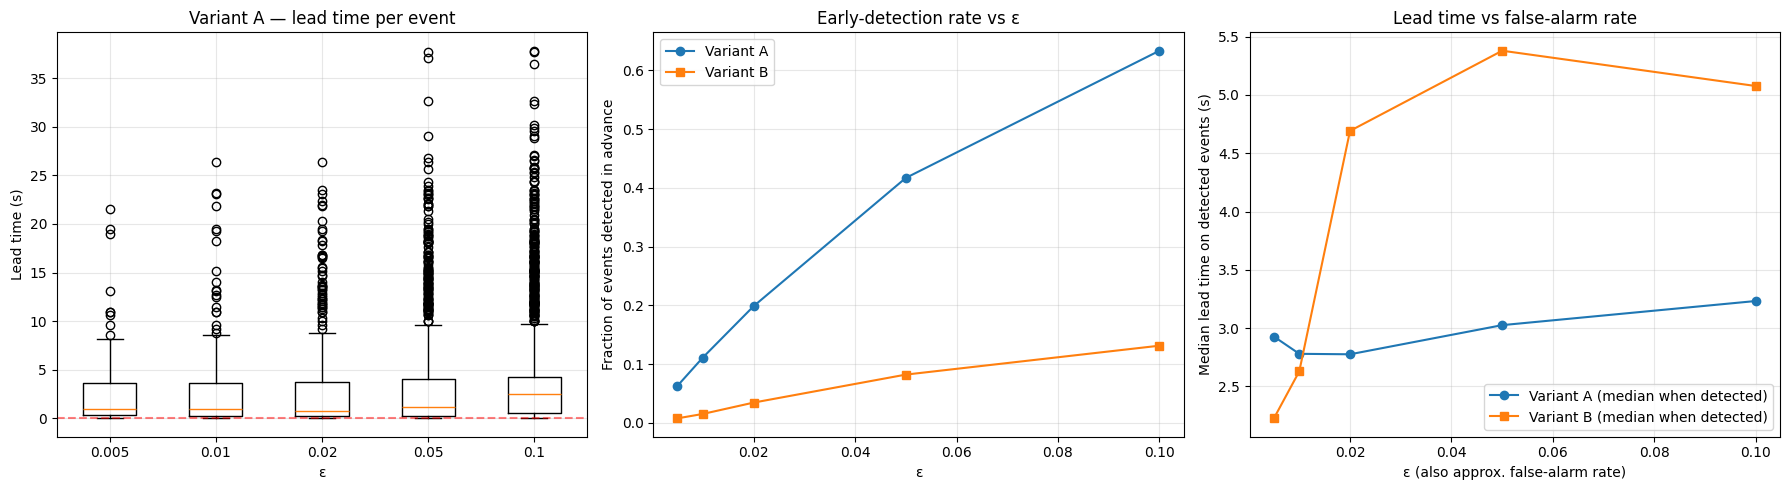

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Lead-time boxplot for Variant A.
ax = axes[0]
data = [lt_A_per_eps[lt_A_per_eps['eps'] == eps]['lead_s'].dropna() for eps in EPSILONS]
ax.boxplot(data, tick_labels=[f'{e}' for e in EPSILONS], showfliers=True)
ax.set_xlabel('ε')
ax.set_ylabel('Lead time (s)')
ax.set_title('Variant A — lead time per event')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# (b) Detection rate vs ε.
ax = axes[1]
det_A = [(lt_A_per_eps[lt_A_per_eps['eps']==e]['lead_s'] > 0).sum() / max(1, len(lt_A_per_eps[lt_A_per_eps['eps']==e])) for e in EPSILONS]
det_B = [(lt_B_per_eps[lt_B_per_eps['eps']==e]['lead_s'] > 0).sum() / max(1, len(lt_B_per_eps[lt_B_per_eps['eps']==e])) for e in EPSILONS]
ax.plot(EPSILONS, det_A, 'o-', label='Variant A')
ax.plot(EPSILONS, det_B, 's-', label='Variant B')
ax.set_xlabel('ε')
ax.set_ylabel('Fraction of events detected in advance')
ax.set_title('Early-detection rate vs ε')
ax.legend(); ax.grid(True, alpha=0.3)

# (c) Lead time vs empirical FA — the headline trade-off.
ax = axes[2]
med_A = [lt_A_per_eps[(lt_A_per_eps['eps']==e) & (lt_A_per_eps['lead_s']>0)]['lead_s'].median() for e in EPSILONS]
med_B = [lt_B_per_eps[(lt_B_per_eps['eps']==e) & (lt_B_per_eps['lead_s']>0)]['lead_s'].median() for e in EPSILONS]
ax.plot(EPSILONS, med_A, 'o-', label='Variant A (median when detected)')
ax.plot(EPSILONS, med_B, 's-', label='Variant B (median when detected)')
ax.set_xlabel('ε (also approx. false-alarm rate)')
ax.set_ylabel('Median lead time on detected events (s)')
ax.set_title('Lead time vs false-alarm rate')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lead_time_tradeoffs.png', dpi=110)
plt.show()

## 5. Save results

In [8]:
lt_A_per_eps.to_csv('lead_time_A.csv', index=False)
lt_B_per_eps.to_csv('lead_time_B.csv', index=False)
summary_A.to_csv('lead_time_summary_A.csv', index=False)
summary_B.to_csv('lead_time_summary_B.csv', index=False)
print('Saved lead_time_A.csv, lead_time_B.csv, lead_time_summary_A.csv, lead_time_summary_B.csv')

Saved lead_time_A.csv, lead_time_B.csv, lead_time_summary_A.csv, lead_time_summary_B.csv
